In [1]:
from default_libs import *  # its a custom library only works in my pc
# it imports all necessary libraries

In [2]:
df=pd.read_csv(r"C:\Users\lette\Data Analytics\Data Visualization\Zomato-data-.csv")

In [3]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [4]:
df.rename(columns={"approx_cost(for two people)":'cost for 2 people','listed_in(type)':'restaurant type'}, inplace=True)

In [5]:
df.head()

,name,online_order,book_table,rate,votes,cost for 2 people,restaurant type
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


## rate column data is not looking good for mathematical calculations

In [6]:
def rate_change(points):
    points=str(points).split('/')
    points=points[0]
    return float(points)

df['rate']=df['rate'].apply(rate_change)
    

In [7]:
df.head()

,name,online_order,book_table,rate,votes,cost for 2 people,restaurant type
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


# Bivariate analysis

## Column Pairs
1. Numerical vs Numerical
2. Numerical vs Categorical
3. Categorical vs Numerical
4. Categorical vs Categorical

## Numerical vs Numerical

In [8]:
# We need to check the following:

# spread ?
# is linearity in the data?
# is outliers ?
# is clusters ?
# is hidden segments ?

### for all these questions we have One solution: SCATTER PLOT

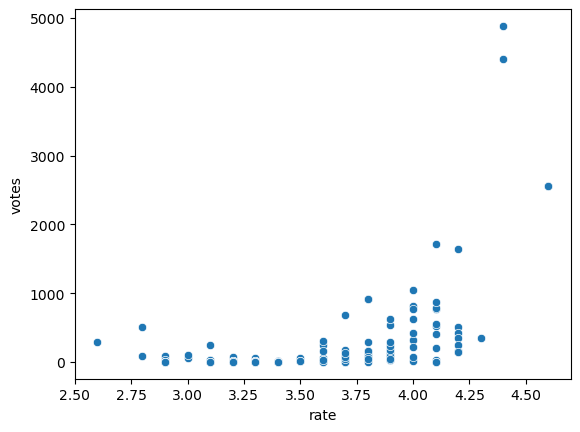

In [9]:
sns.scatterplot(x=df["rate"], y=df["votes"])
plt.show()

In [10]:
# low spread
# has some linearity
# few outliers exists
# no visible clusters
# no hidden segments

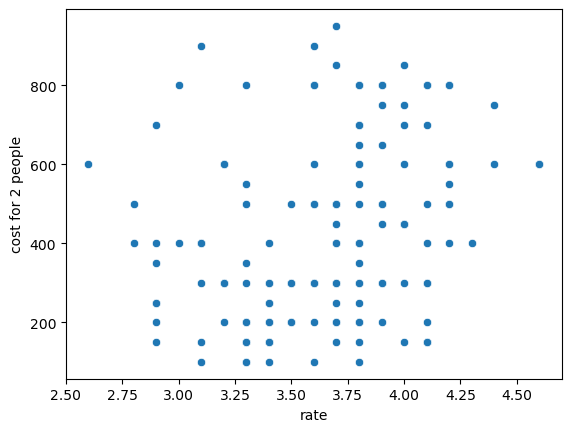

In [11]:
sns.scatterplot(x=df["rate"], y=df["cost for 2 people"])
plt.show()

In [12]:
# high spread
# very low linearity
# no extream outliers
# no hidden segments
# no clusters

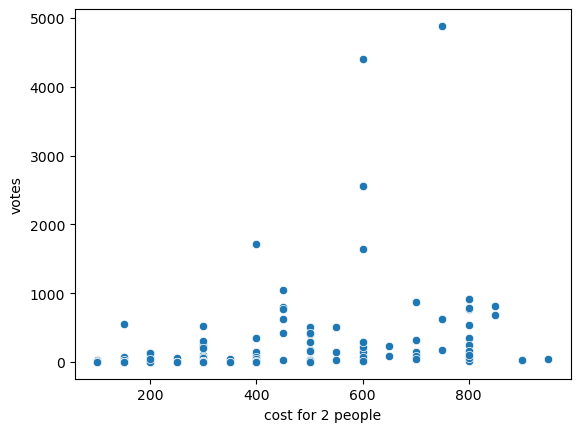

In [13]:
sns.scatterplot(x=df["cost for 2 people"], y=df["votes"])
plt.show()

In [14]:
# low spread 
# only 4 outliers
# data has linearity
# no clusters
# no hidden segments

### We still dont know about,
1. does variables have correlation ?
2. is redundancy exists ? (duplicate values)
3. is multi-collinearity exists ? (highly ralated OR one can compensate for another)

### Final answer is: Heatmap

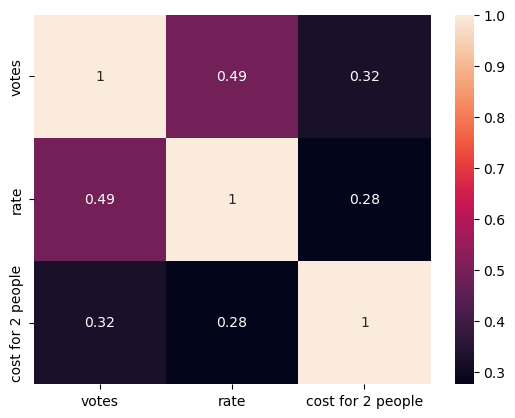

In [15]:
selected_columns=['votes','rate','cost for 2 people']
heatmap_corr=df[selected_columns].corr()
sns.heatmap(heatmap_corr,annot=True)
plt.show()

In [16]:
# 1 is High , and 0 is No correlation

# when variables show +0.8 correlation, they carry same information, that is multi-collinearity 

## Numerical vs Categorical

In [17]:
# we need to check :

# central value
# spread difference
# outliers 
# overlap btw groups

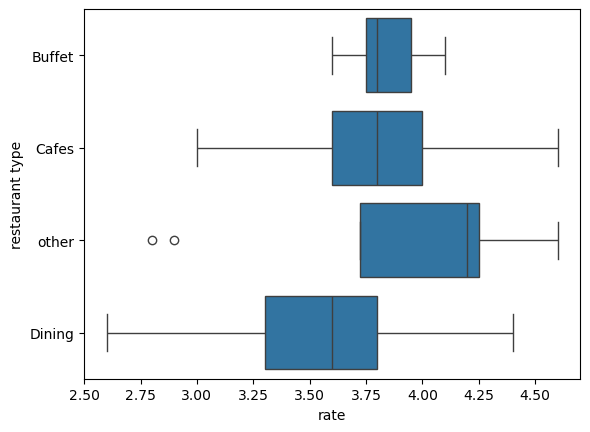

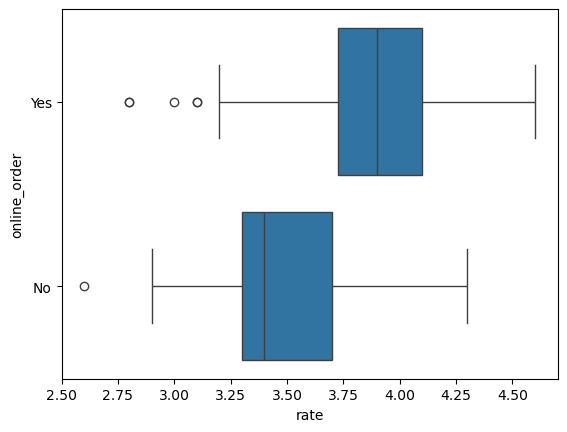

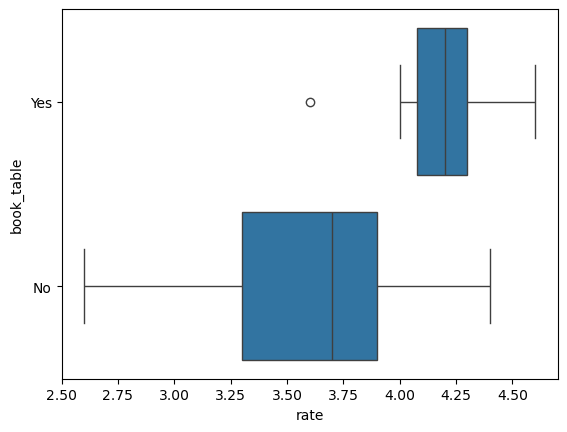

In [18]:
rate_pairs=['restaurant type','online_order','book_table']
for m in rate_pairs:
    sns.boxplot(x=df['rate'],y=df[m])
    plt.show()

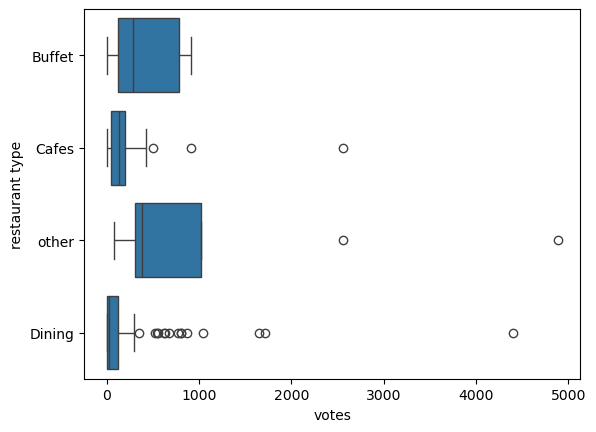

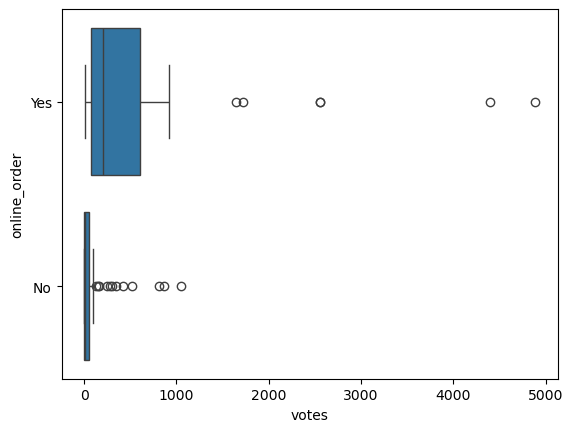

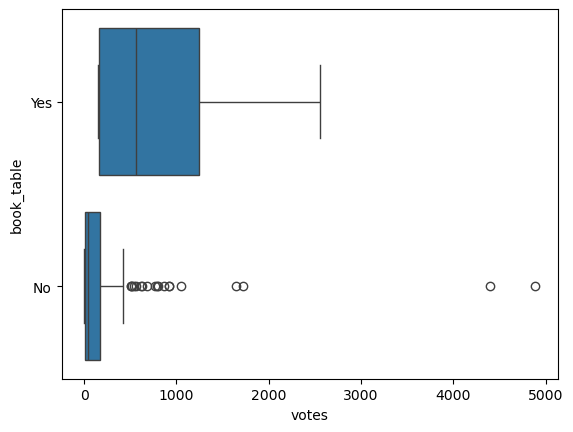

In [19]:
votes_pair=['restaurant type','online_order','book_table']
for j in votes_pair:
    sns.boxplot(x=df['votes'],y=df[j])
    plt.show()

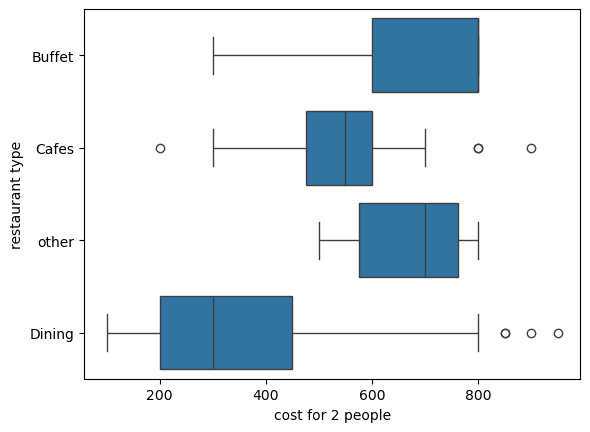

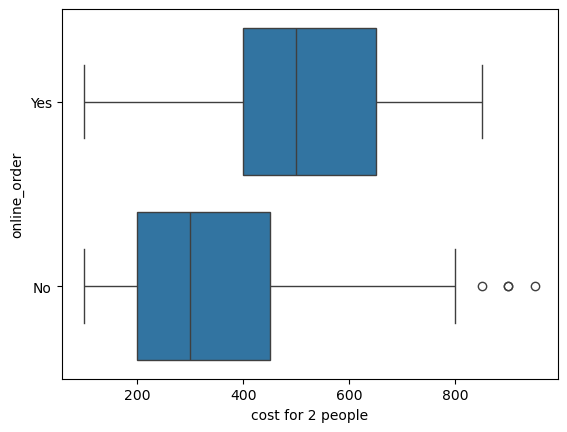

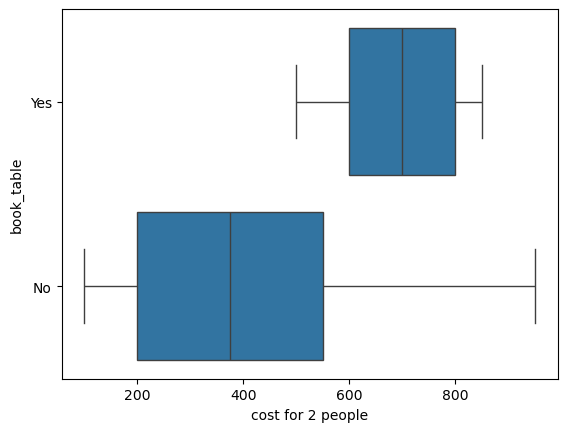

In [20]:
cost_pairs=['restaurant type','online_order','book_table']
for s in cost_pairs:
    sns.boxplot(x=df['cost for 2 people'],y=df[s])
    plt.show()

In [21]:
# Categorical vs Numerical pair is not needed, because analysis doesn't change
# only values shift from x-axis to y-axis

## Categorical vs Categorical

### With counts

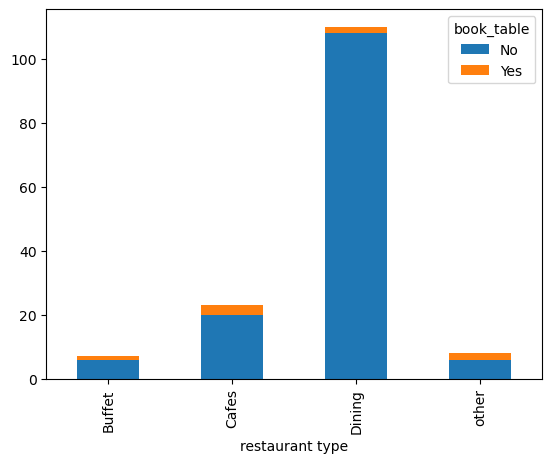

In [22]:
cross_tab=pd.crosstab(df['restaurant type'],df['book_table'])
cross_tab.plot(kind='bar', stacked=True)
plt.show()

### With percentage (for easy understanding)

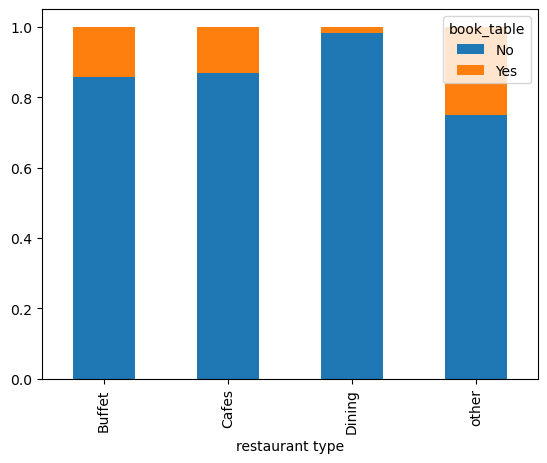

In [23]:
cross_for_percentage=pd.crosstab(df['restaurant type'], df['book_table'], normalize='index')
cross_for_percentage.plot(kind='bar', stacked=True)
plt.show()

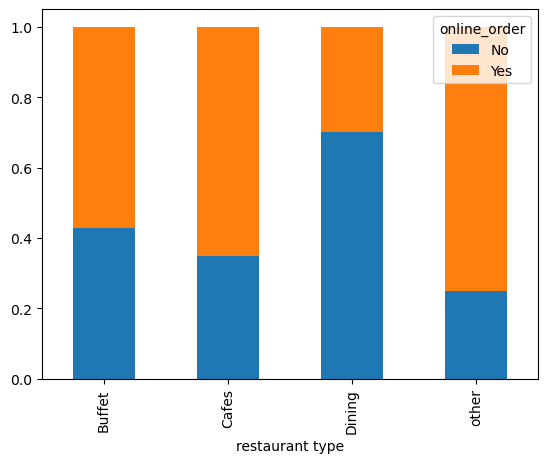

In [24]:
cross_for_percentage=pd.crosstab(df['restaurant type'], df['online_order'], normalize='index')
cross_for_percentage.plot(kind='bar', stacked=True)
plt.show()

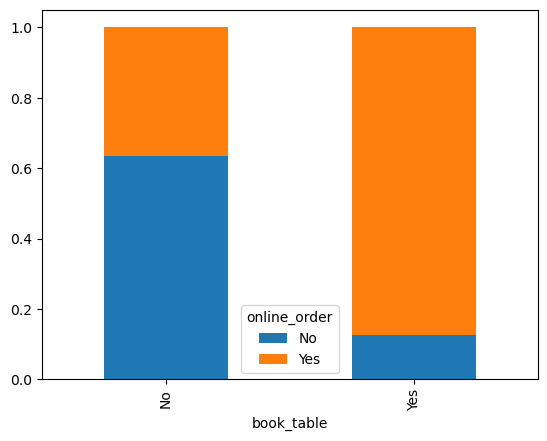

In [25]:
cross_for_percentage=pd.crosstab(df['book_table'], df['online_order'], normalize='index')
cross_for_percentage.plot(kind='bar', stacked=True)
plt.show()